In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch


PROJECT_ROOT = "/home/carol/Research/Celegans_inference"
sys.path.insert(0, PROJECT_ROOT)

In [15]:
# Run a small simulation for trajectory visualization
from utils import simulator_TL
import numpy as np
import torch

# ----------------------------
# Device and simulation config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = 256                 # number of trajectories
T_end = 216.0           # hours
dt_record = 0.2         # hours

record_times = torch.arange(
    dt_record,
    T_end + 1e-9,
    dt_record,
    device=device,
)

# ----------------------------
# Load stratified kappa samples
# ----------------------------
data = np.load("synthetic_data/kappa_samples_Exp1_4gauss.npz")
kappa_all = data["kappa_samples"]   # adjust key if needed

assert kappa_all.ndim == 1
assert len(kappa_all) >= N

# Choose N kappas to use for simulating (deterministic or random)
rng = np.random.default_rng(0)
kappa_smallsample = rng.choice(kappa_all, size=N, replace=False)

# Move to torch
kappa_smallsample = torch.tensor(kappa_smallsample, dtype=torch.float32, device=device)

# ----------------------------
# Parameters
# ----------------------------
alpha = 0.02
mu    = 0.5
d = 0.12
rho = 0.9

params = torch.stack([
    torch.full((N,), alpha, device=device),
    torch.full((N,), mu,    device=device),
    kappa_smallsample,                          # per-trajectory κ
    torch.full((N,), d,     device=device),
    torch.full((N,), rho,     device=device),
], dim=0)   # shape (4, N)

assert params.shape == (5, N)

# ----------------------------
# Run simulator
# ----------------------------
snapshots = simulator_TL.sample_record(
    params=params,
    record_times=record_times,
    N=N,
    device=device,
)

# Stack results
E_mat = torch.stack([s.to("cpu") for s in snapshots], dim=0).numpy()
t_vec = record_times.to("cpu").numpy()

print("E_mat shape:", E_mat.shape)   # (Trec, N)


E_mat shape: (1080, 256)


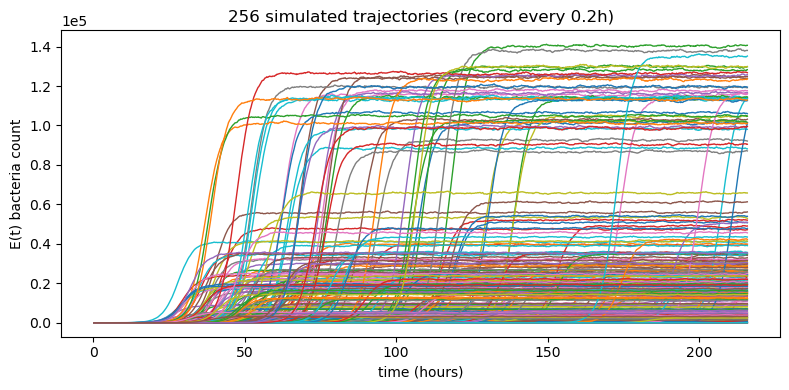

In [16]:
# Cell 11 — Plot all trajectories
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(E_mat.shape[1]):
    ax.plot(t_vec, E_mat[:, i], linewidth=1)

ax.set_xlabel("time (hours)")
ax.set_ylabel("E(t) bacteria count")
ax.set_title("256 simulated trajectories (record every 0.2h)")
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useOffset=False)
plt.tight_layout()
plt.show()


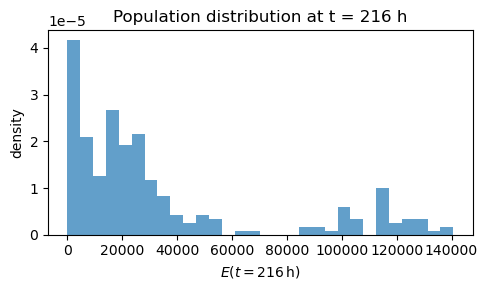

Extinction fraction: 0.03125
κ median (E_final==0): 16093.0
κ median (E_final>0): 20283.5
Ever became nonzero: 0.98828125


In [17]:
# Final-time populations across trajectories
E_final = E_mat[-1, :]   # shape (N,)

plt.figure(figsize=(5, 3))
plt.hist(E_final, bins=30, density=True, alpha=0.7)
plt.xlabel(r"$E(t=216\,\mathrm{h})$")
plt.ylabel("density")
plt.title("Population distribution at t = 216 h")
plt.tight_layout()
plt.show()

# Since many trajectories stay 0 even at the end, let's check the issue of extinction
E_final = E_mat[-1, :]
print("Extinction fraction:", (E_final == 0).mean())

kappa_np = kappa_smallsample.detach().cpu().numpy()
E_final = E_mat[-1, :]

# Compare κ between extinct vs non-extinct
print("κ median (E_final==0):", np.median(kappa_np[E_final == 0]) if (E_final==0).any() else None)
print("κ median (E_final>0):",  np.median(kappa_np[E_final > 0])  if (E_final>0).any() else None)

ever_nonzero = (E_mat > 0).any(axis=0)
print("Ever became nonzero:", ever_nonzero.mean())


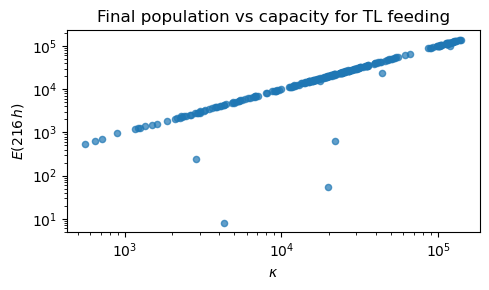

In [18]:
# How many worms reach saturation under these conditions?
kappa_np = kappa_smallsample.detach().cpu().numpy()
E_final = E_mat[-1, :]

plt.figure(figsize=(5,3))
plt.scatter(kappa_np, E_final, s=20, alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\kappa$")
plt.ylabel(r"$E(216\,h)$")
plt.title("Final population vs capacity for TL feeding")
plt.tight_layout()
plt.show()

119 359 599 839 1079
24.0 72.0 120.0 168.0 216.0


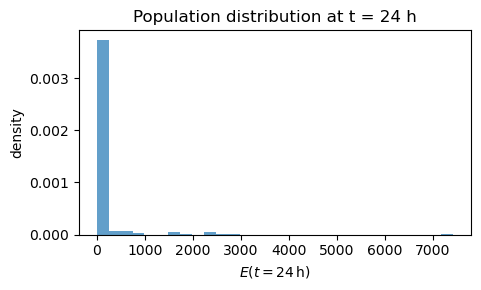

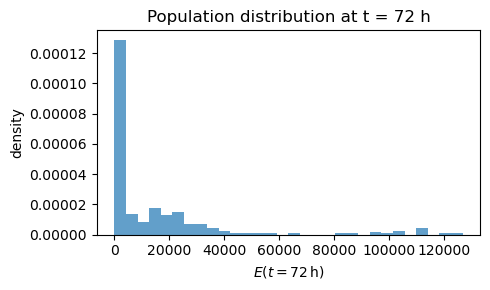

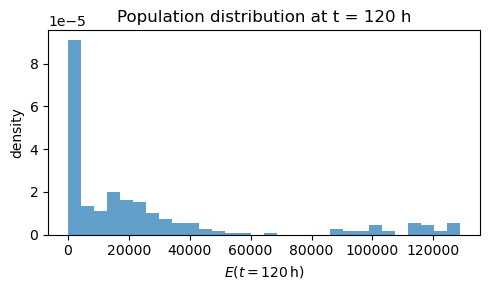

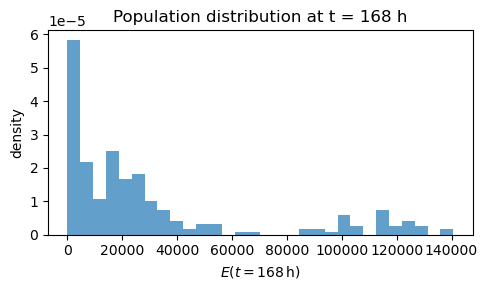

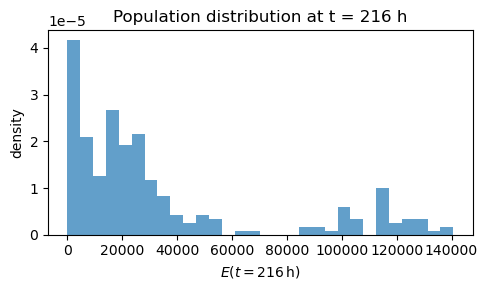

In [19]:
def time_index(t_vec, t_target):
    return int(np.argmin(np.abs(t_vec - t_target)))

idx_24  = time_index(t_vec, 24.0)
idx_72  = time_index(t_vec, 72.0)
idx_120 = time_index(t_vec, 120.0)
idx_168 = time_index(t_vec, 168.0)
idx_216 = time_index(t_vec, 216.0)

print(idx_24, idx_72, idx_120, idx_168, idx_216)
print(t_vec[idx_24], t_vec[idx_72], t_vec[idx_120], t_vec[idx_168], t_vec[idx_216])



for t_label, idx in [(24, idx_24), (72, idx_72), (120, idx_120), (168, idx_168), (216, idx_216)]:
    E_t = E_mat[idx, :]

    plt.figure(figsize=(5, 3))
    plt.hist(E_t, bins=30, density=True, alpha=0.7)
    plt.xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
    plt.ylabel("density")
    plt.title(f"Population distribution at t = {t_label} h")
    plt.tight_layout()
    plt.show()


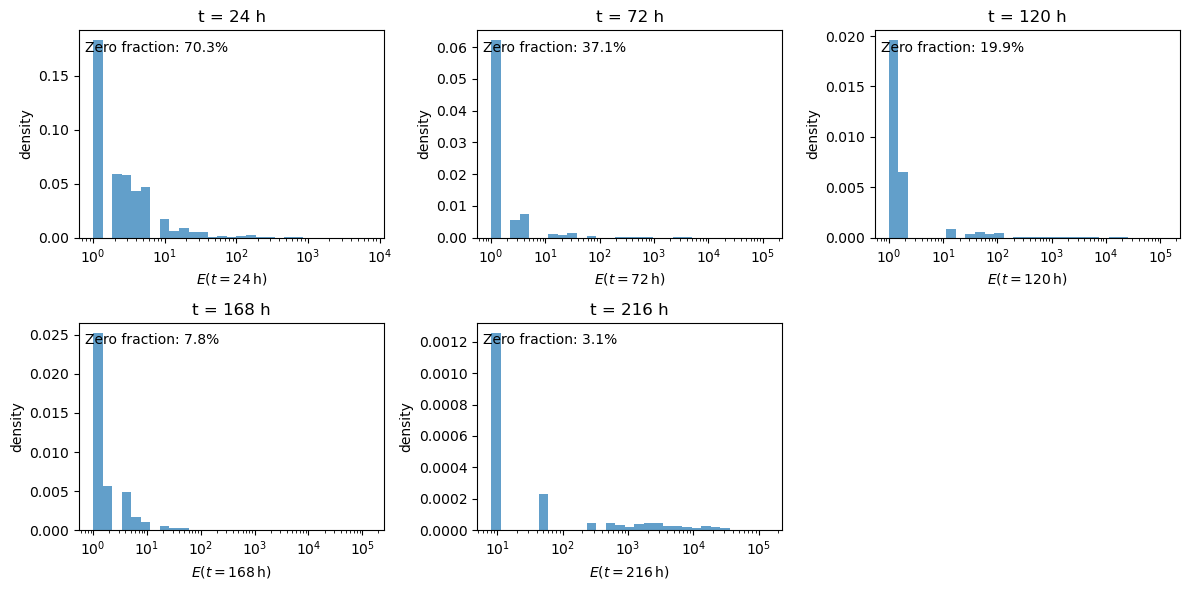

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

time_info = [(24, idx_24), (72, idx_72), (120, idx_120), (168, idx_168), (216, idx_216)]

fig = plt.figure(figsize=(12, 6))
gs = GridSpec(2, 3, figure=fig)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),  
    fig.add_subplot(gs[1, 1]),
]

for ax, (t_label, idx) in zip(axes, time_info):
    E_t = E_mat[idx, :]
    E_pos = E_t[E_t > 0]

    frac_zero = np.mean(E_t == 0)

    if E_pos.size == 0:
        # nothing positive to log-bin; show a simple note
        ax.text(0.5, 0.5, "No E > 0 samples", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"t = {t_label} h")
        ax.set_xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
        ax.set_ylabel("density")
        continue

    # log-spaced bins
    bins = np.logspace(np.log10(E_pos.min()), np.log10(E_pos.max()), 30)

    ax.hist(E_pos, bins=bins, density=True, alpha=0.7)
    ax.set_xscale("log")
    ax.set_xlabel(rf"$E(t={t_label}\,\mathrm{{h}})$")
    ax.set_ylabel("density")
    ax.set_title(f"t = {t_label} h")

    ax.text(
        0.02, 0.95,
        f"Zero fraction: {frac_zero:.1%}",
        transform=ax.transAxes,
        ha="left", va="top"
    )

plt.tight_layout()
plt.show()
